In [4]:
!pip install -q gdown
!gdown --id 1MFQpmbHa5M68f8L0uii_ovJ-toiQblSQ -O dataset.zip
!unzip -oq dataset.zip -d ./
!ls


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
/home/vanadzor-npua/jupyter/venv/lib/python3.12/site-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1MFQpmbHa5M68f8L0uii_ovJ-toiQblSQ
From (redirected): https://drive.google.com/uc?id=1MFQpmbHa5M68f8L0uii_ovJ-toiQblSQ&confirm=t&uuid=6920238b-2e11-482f-b154-365cb283f88f
To: /home/vanadzor-npua/notebooks/yerevan190/dataset.zip
 58%|███████████████████████▍                | 332M/568M [00:13<00:09, 25.4MB/s]^C
Traceback (most recent call last):
  File "/home/vanadzor-npua/jupyter/venv/bin/gdown", line 7, in <module>
    sys.exit(main())
             ^^^^^^
  File "/home/vanadzor-npua/jupyter/venv/lib/python3.12/site-packages/gdown/__main__.py", line 171, in main
    download(
  

In [5]:
!git clone https://github.com/WongKinYiu/yolov9.git
%cd yolov9
!pip install -r requirements.txt -q

fatal: destination path 'yolov9' already exists and is not an empty directory.
/home/vanadzor-npua/notebooks/yerevan190/yolov9

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
!wget -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-c.pt

In [7]:
!nvidia-smi

Sat Feb 28 11:11:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro RTX 8000                On  |   00000000:1A:00.0 Off |                  Off |
| 33%   32C    P8             32W /  260W |       1MiB /  49152MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
import os

dataset_path = "/home/vanadzor-npua/notebooks/yerevan190/combined_dataset"

yaml_content = f"""train: {dataset_path}/train/images
val: {dataset_path}/valid/images
test: {dataset_path}/test/images
nc: 2
names: ['car', 'garbage']
"""

with open(f"{dataset_path}/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml обновлён:")
print(yaml_content)

data.yaml обновлён:
train: /home/vanadzor-npua/notebooks/yerevan190/combined_dataset/train/images
val: /home/vanadzor-npua/notebooks/yerevan190/combined_dataset/valid/images
test: /home/vanadzor-npua/notebooks/yerevan190/combined_dataset/test/images
nc: 2
names: ['car', 'garbage']



In [10]:
import subprocess
result = subprocess.run(['grep', '-n', 'torch.load', '/home/vanadzor-npua/notebooks/yerevan190/yolov9/train_dual.py'], capture_output=True, text=True)
print(result.stdout)

110:        ckpt = torch.load(weights, map_location='cpu')  # load checkpoint to CPU to avoid CUDA memory leak
506:            d = torch.load(last, map_location='cpu')['opt']



In [11]:
import re

filepath = '/home/vanadzor-npua/notebooks/yerevan190/yolov9/train_dual.py'

with open(filepath, 'r') as f:
    content = f.read()

content = content.replace(
    "torch.load(weights, map_location='cpu')",
    "torch.load(weights, map_location='cpu', weights_only=False)"
).replace(
    "torch.load(last, map_location='cpu')",
    "torch.load(last, map_location='cpu', weights_only=False)"
)

with open(filepath, 'w') as f:
    f.write(content)

print("done")

done


In [14]:
filepath = '/home/vanadzor-npua/notebooks/yerevan190/yolov9/utils/augmentations.py'

with open(filepath, 'r') as f:
    content = f.read()

# Делаем copy_paste безопасным
content = content.replace(
    "l, box, s = labels[j], boxes[j], segments[j]",
    "if j >= len(segments): continue\n        l, box, s = labels[j], boxes[j], segments[j]"
)

with open(filepath, 'w') as f:
    f.write(content)

print("done")

done


In [15]:
filepath = '/home/vanadzor-npua/notebooks/yerevan190/yolov9/utils/plots.py'

with open(filepath, 'r') as f:
    content = f.read()

content = content.replace(
    "w, h = self.font.getsize(label)",
    "w, h = self.font.getbbox(label)[2:]"
)

with open(filepath, 'w') as f:
    f.write(content)

print("done")

done


In [17]:
filepath = '/home/vanadzor-npua/notebooks/yerevan190/yolov9/utils/augmentations.py'

with open(filepath, 'r') as f:
    content = f.read()

# Откатываем неправильный патч
content = content.replace(
    "if j >= len(segments): continue\n        l, box, s = labels[j], boxes[j], segments[j]",
    "l, box, s = labels[j], boxes[j], segments[j]"
)

with open(filepath, 'w') as f:
    f.write(content)

print("Откат применён, проверяем строку:")

with open(filepath, 'r') as f:
    lines = f.readlines()
for i, line in enumerate(lines[240:260], start=241):
    print(f"{i}: {line}", end='')

Откат применён, проверяем строку:
241: 
242:         # calculate ioa first then select indexes randomly
243:         boxes = np.stack([w - labels[:, 3], labels[:, 2], w - labels[:, 1], labels[:, 4]], axis=-1)  # (n, 4)
244:         ioa = bbox_ioa(boxes, labels[:, 1:5])  # intersection over area
245:         indexes = np.nonzero((ioa < 0.30).all(1))[0]  # (N, )
246:         n = len(indexes)
247:         for j in random.sample(list(indexes), k=round(p * n)):
248:             if j >= len(segments): continue
249:         l, box, s = labels[j], boxes[j], segments[j]
250:             labels = np.concatenate((labels, [[l[0], *box]]), 0)
251:             segments.append(np.concatenate((w - s[:, 0:1], s[:, 1:2]), 1))
252:             cv2.drawContours(im_new, [segments[j].astype(np.int32)], -1, (1, 1, 1), cv2.FILLED)
253: 
254:         result = cv2.flip(im, 1)  # augment segments (flip left-right)
255:         i = cv2.flip(im_new, 1).astype(bool)
256:         im[i] = result[i]  # cv2.imwrite('de

In [19]:
filepath = '/home/vanadzor-npua/notebooks/yerevan190/yolov9/utils/augmentations.py'

with open(filepath, 'r') as f:
    lines = f.readlines()

# Исправляем строки 248-249
lines[247] = '        for j in random.sample(list(indexes), k=round(p * n)):\n'
lines[248] = '            if j >= len(segments):\n'
lines[249] = '                continue\n'
# Вставляем правильную строку
lines.insert(250, '            l, box, s = labels[j], boxes[j], segments[j]\n')

with open(filepath, 'w') as f:
    f.writelines(lines)

print("Исправлено! Проверяем:")
with open(filepath, 'r') as f:
    lines = f.readlines()
for i, line in enumerate(lines[244:258], start=245):
    print(f"{i}: {line}", end='')

Исправлено! Проверяем:
245:         indexes = np.nonzero((ioa < 0.30).all(1))[0]  # (N, )
246:         n = len(indexes)
247:         for j in random.sample(list(indexes), k=round(p * n)):
248:         for j in random.sample(list(indexes), k=round(p * n)):
249:             if j >= len(segments):
250:                 continue
251:             l, box, s = labels[j], boxes[j], segments[j]
252:             l, box, s = labels[j], boxes[j], segments[j]
253:             segments.append(np.concatenate((w - s[:, 0:1], s[:, 1:2]), 1))
254:             cv2.drawContours(im_new, [segments[j].astype(np.int32)], -1, (1, 1, 1), cv2.FILLED)
255: 
256:         result = cv2.flip(im, 1)  # augment segments (flip left-right)
257:         i = cv2.flip(im_new, 1).astype(bool)
258:         im[i] = result[i]  # cv2.imwrite('debug.jpg', im)  # debug


In [20]:
filepath = '/home/vanadzor-npua/notebooks/yerevan190/yolov9/utils/augmentations.py'

with open(filepath, 'r') as f:
    lines = f.readlines()

# Удаляем дублированную строку 248 (индекс 247)
del lines[247]

with open(filepath, 'w') as f:
    f.writelines(lines)

print("Исправлено! Проверяем:")
with open(filepath, 'r') as f:
    lines = f.readlines()
for i, line in enumerate(lines[244:258], start=245):
    print(f"{i}: {line}", end='')

Исправлено! Проверяем:
245:         indexes = np.nonzero((ioa < 0.30).all(1))[0]  # (N, )
246:         n = len(indexes)
247:         for j in random.sample(list(indexes), k=round(p * n)):
248:             if j >= len(segments):
249:                 continue
250:             l, box, s = labels[j], boxes[j], segments[j]
251:             l, box, s = labels[j], boxes[j], segments[j]
252:             segments.append(np.concatenate((w - s[:, 0:1], s[:, 1:2]), 1))
253:             cv2.drawContours(im_new, [segments[j].astype(np.int32)], -1, (1, 1, 1), cv2.FILLED)
254: 
255:         result = cv2.flip(im, 1)  # augment segments (flip left-right)
256:         i = cv2.flip(im_new, 1).astype(bool)
257:         im[i] = result[i]  # cv2.imwrite('debug.jpg', im)  # debug
258: 


In [21]:
filepath = '/home/vanadzor-npua/notebooks/yerevan190/yolov9/utils/augmentations.py'

with open(filepath, 'r') as f:
    lines = f.readlines()

# Удаляем дублированную строку 251 (индекс 250)
del lines[250]

with open(filepath, 'w') as f:
    f.writelines(lines)

print("Исправлено! Проверяем:")
with open(filepath, 'r') as f:
    lines = f.readlines()
for i, line in enumerate(lines[244:257], start=245):
    print(f"{i}: {line}", end='')

Исправлено! Проверяем:
245:         indexes = np.nonzero((ioa < 0.30).all(1))[0]  # (N, )
246:         n = len(indexes)
247:         for j in random.sample(list(indexes), k=round(p * n)):
248:             if j >= len(segments):
249:                 continue
250:             l, box, s = labels[j], boxes[j], segments[j]
251:             segments.append(np.concatenate((w - s[:, 0:1], s[:, 1:2]), 1))
252:             cv2.drawContours(im_new, [segments[j].astype(np.int32)], -1, (1, 1, 1), cv2.FILLED)
253: 
254:         result = cv2.flip(im, 1)  # augment segments (flip left-right)
255:         i = cv2.flip(im_new, 1).astype(bool)
256:         im[i] = result[i]  # cv2.imwrite('debug.jpg', im)  # debug
257: 


In [22]:
!python train_dual.py \
  --weights yolov9-c.pt \
  --cfg models/detect/yolov9-c.yaml \
  --data /home/vanadzor-npua/notebooks/yerevan190/combined_dataset/data.yaml \
  --epochs 100 \
  --batch 32 \
  --imgsz 640 \
  --device 0 \
  --name eco_vision_run

/home/vanadzor-npua/jupyter/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/vanadzor-npua/notebooks/yerevan190/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
2026-02-27 16:15:00.833641: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-27 16:15:00.893954

In [9]:
import os
os.chdir('/home/vanadzor-npua/notebooks/yerevan190/yolov9')

!python train_dual.py \
  --weights runs/train/eco_vision_run4/weights/last.pt \
  --cfg models/detect/yolov9-c.yaml \
  --data /home/vanadzor-npua/notebooks/yerevan190/combined_dataset/data.yaml \
  --epochs 100 \
  --batch 32 \
  --imgsz 640 \
  --device 0 \
  --name eco_vision_run \
  --resume

/home/vanadzor-npua/jupyter/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/vanadzor-npua/notebooks/yerevan190/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
2026-02-28 11:12:54.406561: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-28 11:12:54.463763

In [10]:
!cat /home/vanadzor-npua/notebooks/yerevan190/combined_dataset/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images
nc: 2
names: ['car', 'garbage']


In [11]:
with open('/home/vanadzor-npua/notebooks/yerevan190/combined_dataset/data.yaml', 'w') as f:
    f.write("""train: /home/vanadzor-npua/notebooks/yerevan190/combined_dataset/train/images
val: /home/vanadzor-npua/notebooks/yerevan190/combined_dataset/valid/images
test: /home/vanadzor-npua/notebooks/yerevan190/combined_dataset/test/images
nc: 2
names: ['car', 'garbage']
""")
print("Done!")

Done!


In [12]:
import os
os.chdir('/home/vanadzor-npua/notebooks/yerevan190/yolov9')

!python train_dual.py \
  --weights runs/train/eco_vision_run4/weights/last.pt \
  --cfg models/detect/yolov9-c.yaml \
  --data /home/vanadzor-npua/notebooks/yerevan190/combined_dataset/data.yaml \
  --epochs 100 \
  --batch 32 \
  --imgsz 640 \
  --device 0 \
  --name eco_vision_run \
  --resume

/home/vanadzor-npua/jupyter/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/vanadzor-npua/notebooks/yerevan190/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
2026-02-28 11:15:21.200295: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-28 11:15:21.256678

In [14]:
filepath = '/home/vanadzor-npua/notebooks/yerevan190/yolov9/utils/general.py'

with open(filepath, 'r') as f:
    content = f.read()

content = content.replace(
    "x = torch.load(f, map_location=torch.device('cpu'))",
    "x = torch.load(f, map_location=torch.device('cpu'), weights_only=False)"
)

with open(filepath, 'w') as f:
    f.write(content)

print("Done!")

Done!


In [16]:
import os
runs_dir = '/home/vanadzor-npua/notebooks/yerevan190/yolov9/runs/train/'
for run in os.listdir(runs_dir):
    weights_path = os.path.join(runs_dir, run, 'weights')
    if os.path.exists(weights_path):
        files = os.listdir(weights_path)
        print(f"{run}: {files}")

eco_vision_run3: []
eco_vision_run: []
eco_vision_run2: []
eco_vision_run4: ['last.pt', 'best.pt']


In [18]:
import os
run_dir = '/home/vanadzor-npua/notebooks/yerevan190/yolov9/runs/train/eco_vision_run4/'
print(os.listdir(run_dir))

['results.csv', 'opt.yaml', 'train_batch1.jpg', 'train_batch2.jpg', 'train_batch0.jpg', 'events.out.tfevents.1772289573.ubuntu.1487111.0', 'weights', 'hyp.yaml', 'events.out.tfevents.1772277208.ubuntu.1405950.0', 'events.out.tfevents.1772277354.ubuntu.1406541.0', 'events.out.tfevents.1772208934.ubuntu.980179.0', 'labels.jpg', 'labels_correlogram.jpg']


In [19]:
import pandas as pd

df = pd.read_csv('/home/vanadzor-npua/notebooks/yerevan190/yolov9/runs/train/eco_vision_run4/results.csv')
df.columns = df.columns.str.strip()
print(df.tail(5).to_string())

    epoch  train/box_loss  train/cls_loss  train/dfl_loss  metrics/precision  metrics/recall  metrics/mAP_0.5  metrics/mAP_0.5:0.95  val/box_loss  val/cls_loss  val/dfl_loss     x/lr0     x/lr1     x/lr2
95     95          1.0625         0.78474          1.4859            0.76960         0.70879          0.75315               0.49794             0             0             0  0.000694  0.000694  0.000694
96     96          1.0429         0.76909          1.4824            0.75732         0.71855          0.75445               0.49773             0             0             0  0.000595  0.000595  0.000595
97     97          1.0427         0.76924          1.4736            0.76220         0.71499          0.75348               0.49858             0             0             0  0.000496  0.000496  0.000496
98     98          1.0345         0.75660          1.4668            0.76555         0.71889          0.75491               0.50043             0             0             0  0.000397 

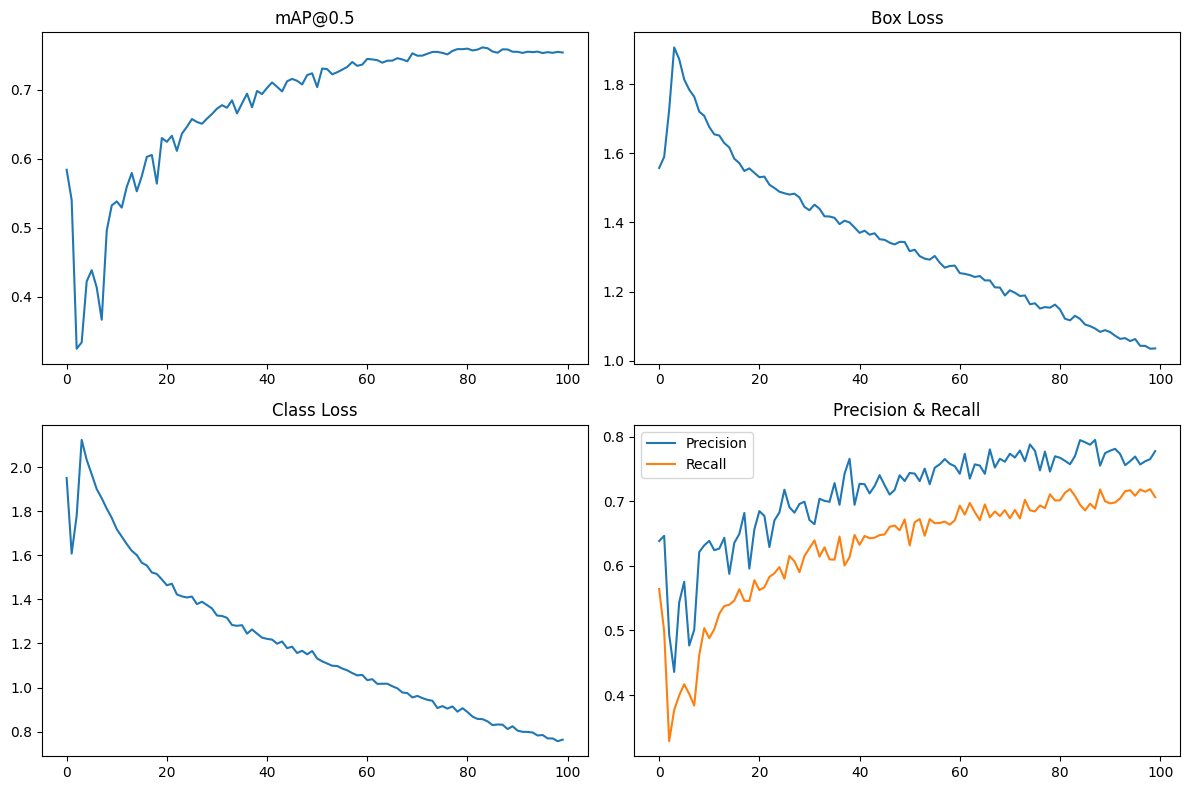

Graph save!


In [21]:
import matplotlib.pyplot as plt

df = pd.read_csv('/home/vanadzor-npua/notebooks/yerevan190/yolov9/runs/train/eco_vision_run4/results.csv')
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(df['epoch'], df['metrics/mAP_0.5'])
axes[0,0].set_title('mAP@0.5')

axes[0,1].plot(df['epoch'], df['train/box_loss'])
axes[0,1].set_title('Box Loss')

axes[1,0].plot(df['epoch'], df['train/cls_loss'])
axes[1,0].set_title('Class Loss')

axes[1,1].plot(df['epoch'], df['metrics/precision'], label='Precision')
axes[1,1].plot(df['epoch'], df['metrics/recall'], label='Recall')
axes[1,1].legend()
axes[1,1].set_title('Precision & Recall')

plt.tight_layout()
plt.savefig('training_results.png')
plt.show()
print("Graph save!")